## Imports

In [1]:
import csv
import cv2
import numpy as np
import time
import uuid
import json

from datetime import datetime
from matplotlib import pyplot as plt
from skimage.io import imshow, show
from LPIQE.src.LPIQE_reconstruction_executor import  LpiqeReconstructionExecutor as recon
from LPIQE.src.LPIQE_qiskit_implementation import  LpiqeQiskit
from PDU.src.PDU_function_creator import PDUFunctionCreator
from PDU.src.PDU_statistics_helper import PDUStatisticsHelper
from qiskit_aer import Aer

## Class setup

In [2]:
lpique_impl=LpiqeQiskit()
backend = 'ibm_kyiv'
api_key = '634a567fdd43f08aa7dcc192b4aa09ed3a7af2ed038820b2b11df9b51e0255a4d8b129932cc2607b081d010860fadd6794a6da609e2015dabf7fe5ecfceabe87'
hub = 'ibm-q'
group = 'open'
project = 'main'
params = [True, api_key, hub, group, project, backend]

image_shape = (16,16)
executor=recon(lpique_impl, image_shape, params)
pdu_function_creator = PDUFunctionCreator(True, image_shape, executor, 32000)
pdu_statistics_helper = PDUStatisticsHelper()

IBMApiError: 'Unexpected response received from server. Please check if the service is in maintenance mode https://docs.quantum.ibm.com/announcements/service-alerts.'

## Helper functions

In [3]:
def save_results(data):
    with open('experiment_results.csv', mode='a', newline='') as results:
        results_writer = csv.writer(results, delimiter=';', quotechar='"', quoting=csv.QUOTE_MINIMAL)
        results_writer.writerow(data)
        results.close()

## Calibration PDU function

In [4]:

calibration_granularity = 5

pdu_function_creator.create_empty_function()
pdu_function_creator.calibrate_function(calibration_granularity)
time_of_calibrating_pdu = datetime.now().replace(tzinfo=None)

Calibrating PDU function


KeyboardInterrupt: 

## EDGE DETECTION

### Image

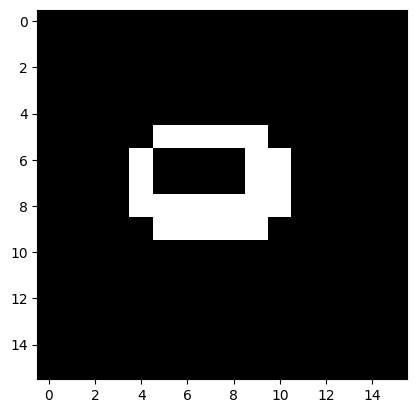

In [3]:
# img_data = np.array([
#     [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
#     [0,0,0,1,1,1,1,0,0,0,0,0,0,0,0,0],
#     [0,0,1,1,1,1,1,1,0,0,0,0,0,0,0,0],
#     [0,0,1,1,1,1,1,1,0,0,0,0,0,0,0,0],
#     [0,0,0,1,1,1,1,0,0,0,0,0,0,0,0,0],
#     [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
#     [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
#     [0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0],
#     [0,0,1,1,1,1,1,0,0,0,0,0,1,1,1,0],
#     [0,1,1,1,1,1,1,1,1,0,0,1,1,1,1,0],
#     [0,1,1,1,1,0,0,0,1,1,1,1,1,1,1,0],
#     [0,0,0,0,0,0,0,0,0,0,1,1,1,1,1,0],
#     [0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0],
#     [0,0,0,0,0,1,1,0,0,0,0,1,1,0,0,0],
#     [0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0],
#     [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
# ])


img_data = np.array([
    [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
    [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
    [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
    [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
    [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
    [0,0,0,0,0,1,1,1,1,1,0,0,0,0,0,0],
    [0,0,0,0,1,0,0,0,0,1,1,0,0,0,0,0],
    [0,0,0,0,1,0,0,0,0,1,1,0,0,0,0,0],
    [0,0,0,0,1,1,1,1,1,1,1,0,0,0,0,0],
    [0,0,0,0,0,1,1,1,1,1,0,0,0,0,0,0],
    [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
    [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
    [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
    [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
    [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
    [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
])

# Calculate the RMS value
rms = np.sqrt(np.sum(np.sum(img_data**2, axis=1)))

# Create normalized image
image = []
for arr in img_data:
    for ele in arr:
        if rms==0:
            image.append(0)
        else:
            image.append(ele / rms)

plt.imshow(image, cmap='gray')
plt.show()

## Encode images as circuits

## Simulate and show

Quantum computation started: 
1. Transpilation started...
   Circuit is transpiled.
2. Preparing a job.
   Job is prepared.
3. Sending job to execution
  Job is executed


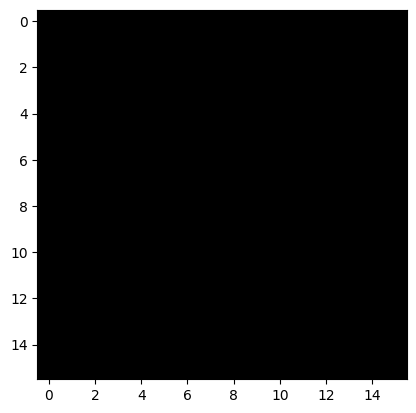

Quantum computation started: 
1. Transpilation started...
   Circuit is transpiled.
2. Preparing a job.
   Job is prepared.
3. Sending job to execution
  Job is executed


IndexError: index 17 is out of bounds for axis 0 with size 16

In [4]:
backend = Aer.get_backend('statevector_simulator')

executor.create_circuit(image)
circ_h = executor.circuit


executor.create_circuit(image.T)
circ_v = executor.circuit

circ_list = [circ_h, circ_v]

results = backend.run(circ_list).result()
sv_h = results.get_statevector(circ_h)
sv_v = results.get_statevector(circ_v)

edge_scan_h_gradient = np.abs(np.array([sv_h[2*i+1].real for i in range(2**8)])).reshape(16, 16)
edge_scan_v_gradient = np.abs(np.array([sv_v[2*i+1].real for i in range(2**8)])).reshape(16, 16)

plt.imshow(executor.reconstructed_image, cmap='gray')
plt.show()

plt.imshow(executor.reconstructed_image, cmap='gray')
plt.show()

## Combine the results

_________________________________________


c:\git\prv\LPIQE-and-PDU\.venv\Lib\site-packages\skimage\io\_plugins\matplotlib_plugin.py:158: UserWarning: Low image data range; displaying image with stretched contrast.
  lo, hi, cmap = _get_display_range(image)


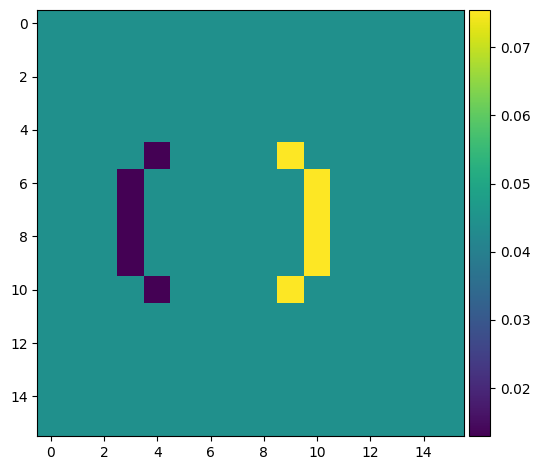

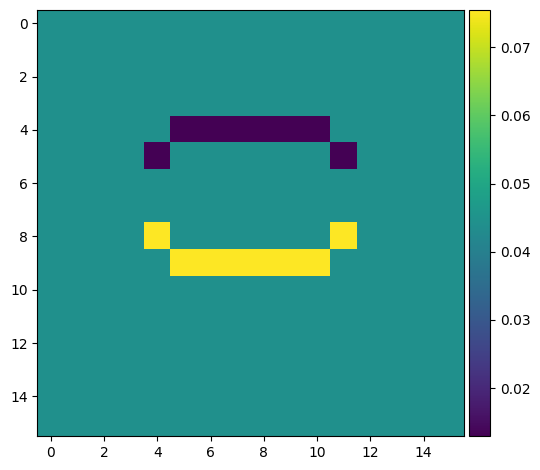

In [55]:
threshold = lambda amp: (amp > 0.05 or amp < -0.05)

edge_scan_h_gradient = np.abs(np.array([sv_h[2*i+1].real for i in range(2**8)])).reshape(16, 16)
edge_scan_v_gradient = np.abs(np.array([sv_v[2*i+1].real for i in range(2**8)])).reshape(16, 16)




midpoint = int(edge_scan_h_gradient.shape[0]/2)

a = edge_scan_h_gradient[:midpoint]
b = np.flip(edge_scan_h_gradient[midpoint:], 0)

edge_scan_h_gradient2 = np.vstack((a, b))

midpoint = int(edge_scan_v_gradient.shape[0]/2)

a = edge_scan_v_gradient[:midpoint]
b = np.flip(edge_scan_v_gradient[midpoint:], 0)

edge_scan_v_gradient3 = np.vstack((a, b)).T



print("_________________________________________")
imshow(edge_scan_h_gradient2)
plt.show()
print("  ")
imshow(edge_scan_v_gradient3)
plt.show()

In [56]:
edge_scan_sim_gradient = edge_scan_h_gradient2 | edge_scan_v_gradient3

imshow(edge_scan_sim_gradient)
plt.show()

plt.imshow(image, cmap='gray')
plt.show()

TypeError: ufunc 'bitwise_or' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''